# Intermediate Measurements
The mesurement function in spec-IA can intermidedly save regions. This is useful for large ammounts of data or if you want to re-start functions without redoing previous measurements.
It also allows you to check in on a measurement while its running. This notebook is a quick example of how to do that.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob

### Making intermediate files
This is just to make an example - you can skip this section if you already have the files.

In [2]:
from alignment_functions.gal_multiplets import *

In [3]:
# simillar to basic_multiplet_alignment-sims.ipynb
n_batches = 10 # there will be 10 intermeditae files
sample = Table.read('example_catalogs/abacus_comoving-points.fits')
save_directory = 'example_output'
# line of sight (LOS): every LOS is along the z axis. For an observer at a point, use los_mode='radial', los_location=[x, y, z]
rp_bin_edges = np.logspace(np.log10(5), np.log10(100), 16)
alignment_result = get_MIA_from3D(sample['x_L2com'], R_bins = rp_bin_edges, save_directory=save_directory, print_info=True, sim_label='example', periodic_boundary=True, transverse_max = 1, los_max=1, n_batches = n_batches, los_mode='axis', los_axis='z',
                                  save_intermediate=True) # this is the one argument added. 

Calculating MIA for 1279967 points with LOS losz
Finding multiplets


Found 30489 multiplets averange number of members: 2.047001
Multiplet size counts:
size: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
counts: [np.int64(29117), np.int64(1314), np.int64(55), np.int64(3)]
Using box_size = [1959.9935 1999.997  1999.9978]


Results base path: example_output/MIA_16bins_5.0_100.0_counts1279967_simexample_losz_10batches_
Dispatching 10 batches across 1 workers


working on batch 0 sim: example


Results saved to  example_output/MIA_16bins_5.0_100.0_counts1279967_simexample_losz_10batches_.fits


### Plotting intermediate files

In [4]:
save_directory = 'example_output'
all_intermediate_files = glob.glob(save_directory + '/*_simexample_losz_*batches_*.npy')
# file names include the sim label and the LOS ('losz' here). make sure this collects only the intermediate results from the run you want. You will need to make this more specific if you are saving multipelt types of measurements in the same directory.
print('N intermediate files found:', len(all_intermediate_files))

N intermediate files found: 10


In [5]:
# go through the existing files and average them
all_pa_rels = []
for test in all_intermediate_files:
    all_pa_rels.append(np.load(test))
pa_rel_av = np.nanmean(all_pa_rels, axis=0)
pa_rel_e = np.nanstd(all_pa_rels, axis=0) / np.sqrt(len(all_pa_rels))

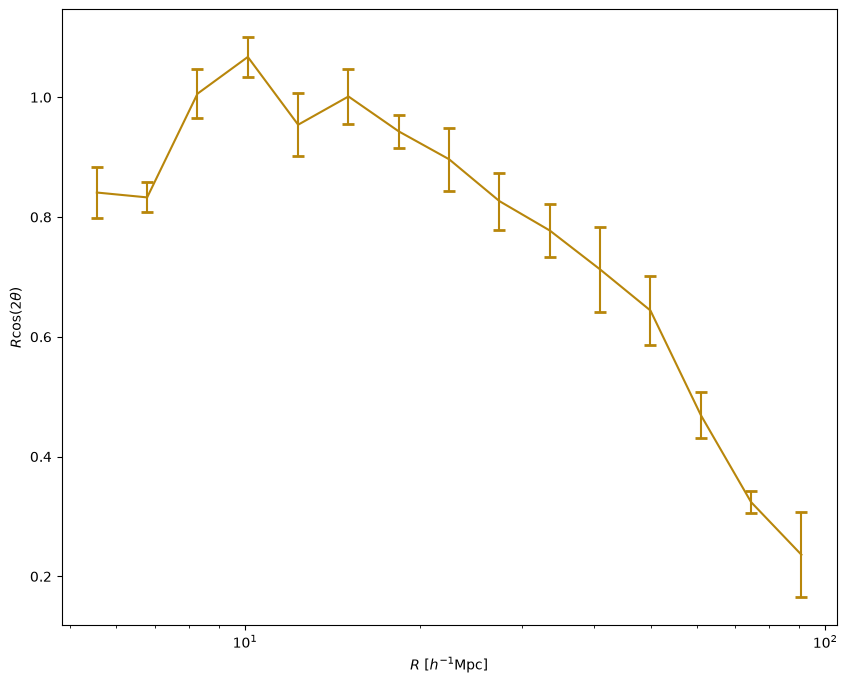

In [6]:
rp_bin_edges = np.logspace(np.log10(5), np.log10(100), 16)
R_bin_middles = (rp_bin_edges[1:] + rp_bin_edges[:-1])/2

fig = plt.figure(figsize=(10,8))
plt.errorbar(R_bin_middles, R_bin_middles*pa_rel_av, yerr=R_bin_middles*pa_rel_e, capsize=4, capthick=2, label='intermediate '+str(len(all_intermediate_files)), color='darkgoldenrod')
plt.xlabel(r'$R$ [$h^{-1}$Mpc]')
plt.ylabel(r'$R\cos(2\theta )$')
plt.xscale('log');

#